In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import plotly.express as px

In [2]:
data = pd.read_csv('coupon/data/coupons.csv')

In [3]:
data.shape

(12684, 26)

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   destination           12684 non-null  str  
 1   passanger             12684 non-null  str  
 2   weather               12684 non-null  str  
 3   temperature           12684 non-null  int64
 4   time                  12684 non-null  str  
 5   coupon                12684 non-null  str  
 6   expiration            12684 non-null  str  
 7   gender                12684 non-null  str  
 8   age                   12684 non-null  str  
 9   maritalStatus         12684 non-null  str  
 10  has_children          12684 non-null  int64
 11  education             12684 non-null  str  
 12  occupation            12684 non-null  str  
 13  income                12684 non-null  str  
 14  car                   108 non-null    str  
 15  Bar                   12577 non-null  str  
 16  CoffeeHouse    

In [5]:
data.head(5)

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


In [6]:
data.tail()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
12679,Home,Partner,Rainy,55,6PM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,1
12680,Work,Alone,Rainy,55,7AM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,0,1,1
12681,Work,Alone,Snowy,30,7AM,Coffee House,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,0
12682,Work,Alone,Snowy,30,7AM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,1,0,1,0
12683,Work,Alone,Sunny,80,7AM,Restaurant(20-50),2h,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,0


In [6]:
data.isnull().sum().sum() 

np.int64(13370)

In [9]:
data.isna().sum().sum()

np.int64(13370)

In [38]:
null_columns = data.columns[data.isnull().any()]
print(null_columns)

Index(['car', 'Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20',
       'Restaurant20To50'],
      dtype='str')


In [18]:
# since the value are strings, ill leave it as NaN. Also i havent referred to this information in my analysis.
print(data['car'].value_counts(dropna=False))
#data['car'].fillna(int(data['car']).mean(), inplace=True)

car
NaN                                         12576
Scooter and motorcycle                         22
Mazda5                                         22
do not drive                                   22
crossover                                      21
Car that is too old to install Onstar :D       21
Name: count, dtype: int64


In [23]:
# will replace Nan with 'never' as the NaN values are less
print(data['Bar'].value_counts(dropna=False))
data.fillna({'Bar': 'never'}, inplace = True)


Bar
never    5304
less1    3482
1~3      2473
4~8      1076
gt8       349
Name: count, dtype: int64


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12679,Home,Partner,Rainy,55,6PM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,1
12680,Work,Alone,Rainy,55,7AM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,0,1,1
12681,Work,Alone,Snowy,30,7AM,Coffee House,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,0
12682,Work,Alone,Snowy,30,7AM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,1,0,1,0


In [34]:
# will replace Nan with 'less1' as the NaN values are less
print(data['CoffeeHouse'].value_counts(dropna=False))
data.fillna({'CoffeeHouse': 'less1'}, inplace = True)
print(data['CoffeeHouse'].value_counts(dropna=False))

CoffeeHouse
less1    3385
1~3      3225
never    2962
4~8      1784
gt8      1111
Less1     217
Name: count, dtype: int64
CoffeeHouse
less1    3602
1~3      3225
never    2962
4~8      1784
gt8      1111
Name: count, dtype: int64


In [35]:
# Will replace Nan with '1~3' since Nan is a very tiny proportion and '1~3' has the highest values.
print(data['CarryAway'].value_counts(dropna=False))
data.fillna({'CarryAway': '1~3'}, inplace = True)
print(data['CarryAway'].value_counts(dropna=False))

CarryAway
1~3      4672
4~8      4258
less1    1856
gt8      1594
never     153
NaN       151
Name: count, dtype: int64
CarryAway
1~3      4823
4~8      4258
less1    1856
gt8      1594
never     153
Name: count, dtype: int64


In [36]:
# Will replace Nan with '1~3' since Nan is a very tiny proportion and '1~3' has the highest values.
print(data['RestaurantLessThan20'].value_counts(dropna=False))
data.fillna({'RestaurantLessThan20': '1~3'}, inplace = True)
print(data['RestaurantLessThan20'].value_counts(dropna=False))

RestaurantLessThan20
1~3      5376
4~8      3580
less1    2093
gt8      1285
never     220
NaN       130
Name: count, dtype: int64
RestaurantLessThan20
1~3      5506
4~8      3580
less1    2093
gt8      1285
never     220
Name: count, dtype: int64


In [38]:
# Will replace Nan with 'less1' since Nan is a very tiny proportion and 'less1' has the highest values.
print(data['Restaurant20To50'].value_counts(dropna=False))
data.fillna({'Restaurant20To50': 'less1'}, inplace = True)
print(data['Restaurant20To50'].value_counts(dropna=False))

Restaurant20To50
less1    6077
1~3      3290
never    2136
4~8       728
gt8       264
NaN       189
Name: count, dtype: int64
Restaurant20To50
less1    6266
1~3      3290
never    2136
4~8       728
gt8       264
Name: count, dtype: int64


In [46]:
#building 2 different data frames for the Y= 0 and 1 values. Around 56% of the people accepted the coupons
coupon_Yes= data[data['Y']==1]
coupon_No= data[data['Y']==0]
proportionaccepted = len(coupon_Yes.index)/len(data)
print(proportionaccepted)

0.5684326710816777


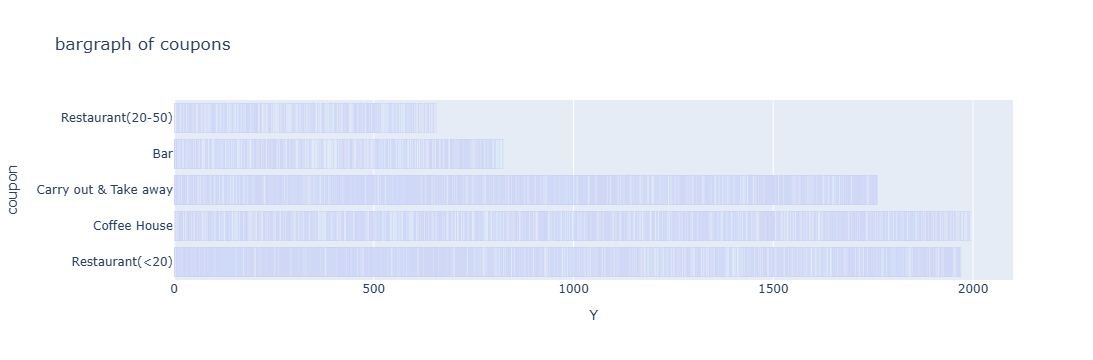

In [51]:
px.bar(
    data, 
    x="Y", 
    y="coupon", 
    barmode="group",   # Places bars side-by-side (use 'stack' to stack them)
    title="bargraph of coupons"
 )

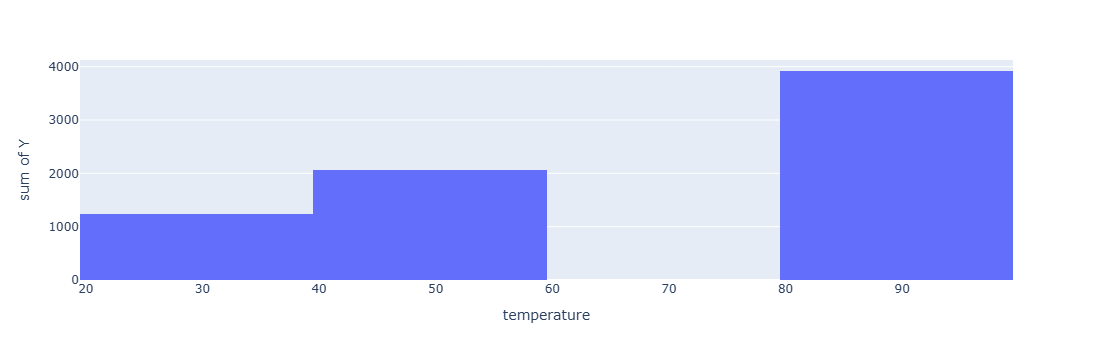

In [52]:
px.histogram(data_frame=data , x='temperature', y='Y')



In [21]:
# Around 41 % of people accepted the bar coupons
coupon_bar=data[data['coupon']=='Bar']
coupon_bar_accepted = coupon_bar[coupon_bar['Y']==1]
print( len(coupon_bar), len(coupon_bar_accepted))
coupon_bar_accepted_proportion=len(coupon_bar_accepted)/len(coupon_bar)
print(coupon_bar_accepted_proportion)

2017 827
0.41001487357461575


In [22]:
coupon_bar_accepted['Bar'].value_counts()

Bar
1~3      257
less1    253
never    156
4~8      117
gt8       36
Name: count, dtype: int64

In [23]:
# the people who go fewer times seem to have accepted 4 times more than the people who go a lot more times. Its like theu go fewer times and once they got the
# coupon they decided to go
coupon_bar_lessthan3 = coupon_bar_accepted.query("Bar=='less1' or Bar=='1~3' or Bar=='never' " )
coupon_bar_greaterthan3 = coupon_bar_accepted.query("Bar=='4~8' or Bar=='gt8' " )
coupon_accepted_proportion= len(coupon_bar_lessthan3)/len(coupon_bar_greaterthan3)
print(coupon_accepted_proportion)

4.352941176470588


In [24]:
data['age'].value_counts()

age
21         2653
26         2559
31         2039
50plus     1788
36         1319
41         1093
46          686
below21     547
Name: count, dtype: int64

In [28]:

coupon_bar_morethan1andover25 = coupon_bar_accepted.query("(Bar=='4~8' or Bar=='1~3' or Bar=='gt8')and age > '25' " )

print(len(coupon_bar_morethan1andover25))
indices_to_drop = coupon_bar_morethan1andover25.index
print(len(indices_to_drop))
coupon_others = coupon_bar_accepted.drop(indices_to_drop, inplace=False)
print(len(coupon_others))

296
296
531


In [32]:
# 55% of the people who acccepted seem to be over 25 and go more than 3 times.
proportion=len(coupon_bar_morethan1andover25)/len(coupon_others)
print(proportion)

0.5574387947269304


#A slightly higher proportion of people who have accepted the coupon dont seem to have kids and seem to prefer restaurant(<20) or Carry out & Take Away or coffee shop . They didnt seem to care either way for
#  Restaurants (20-50).They didnt prefer Bars.
px.histogram(data_frame=data , x='coupon', y='Y', color='has_children')

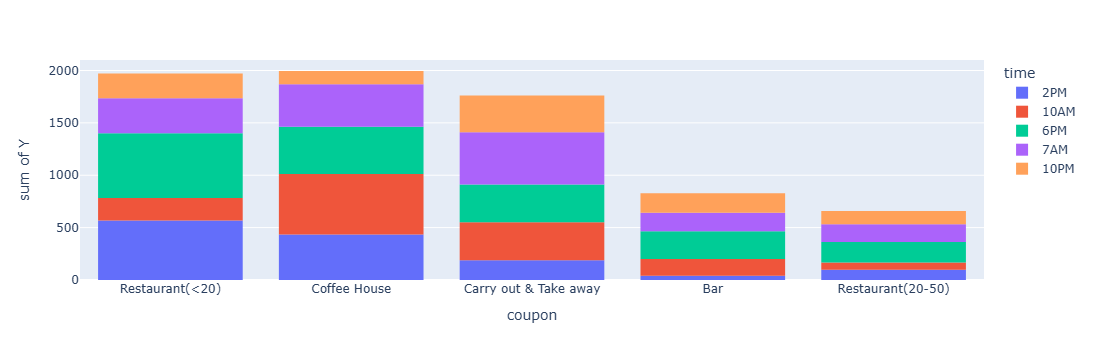

In [37]:
# different timings are preferale for different coupons e.g. 2 or 6 pm are preferred for restaurants (< 20) and 10 am for coffee shops or 7 am or night for take aways.
px.histogram(data_frame=data , x='coupon', y='Y', color='time')

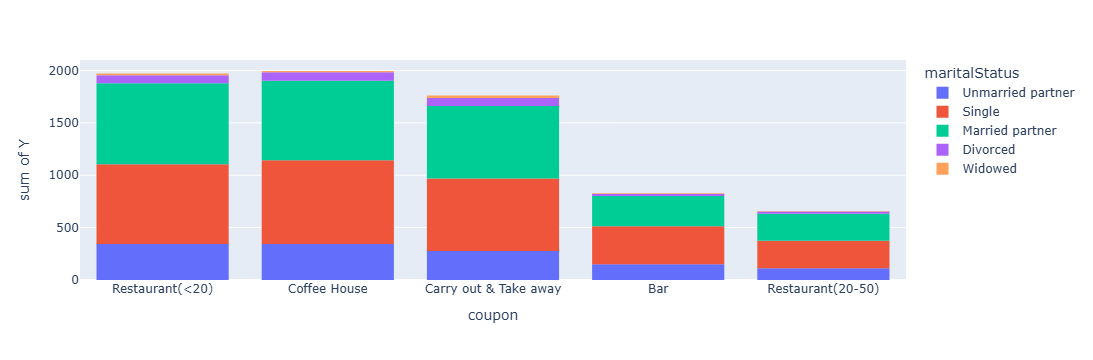

In [41]:
# It looks like Single and Married partners accept the coupons the most compared to other status irrespective of the type of coupon.
px.histogram(data_frame=data, x='coupon', y='Y', color='maritalStatus')

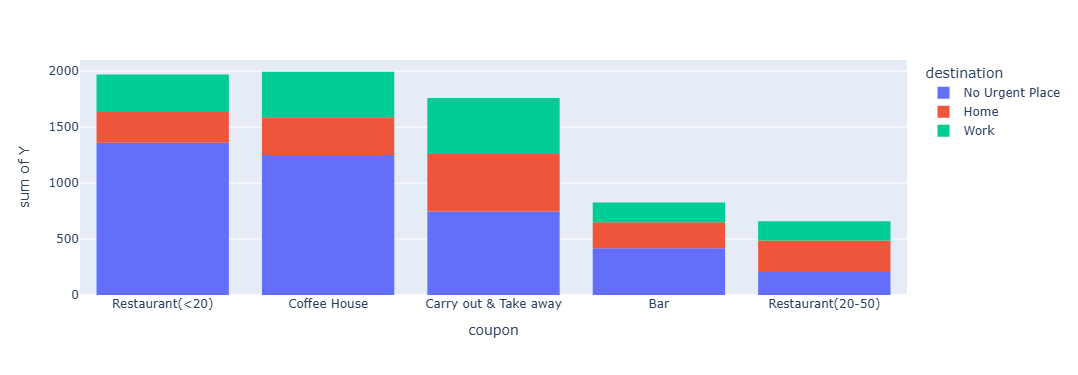

In [42]:
#Most people who accepted coupons had No Urgent Place to go to irrespective of the type of coupon they received.
px.histogram(data_frame=data, x='coupon', y='Y', color='destination')

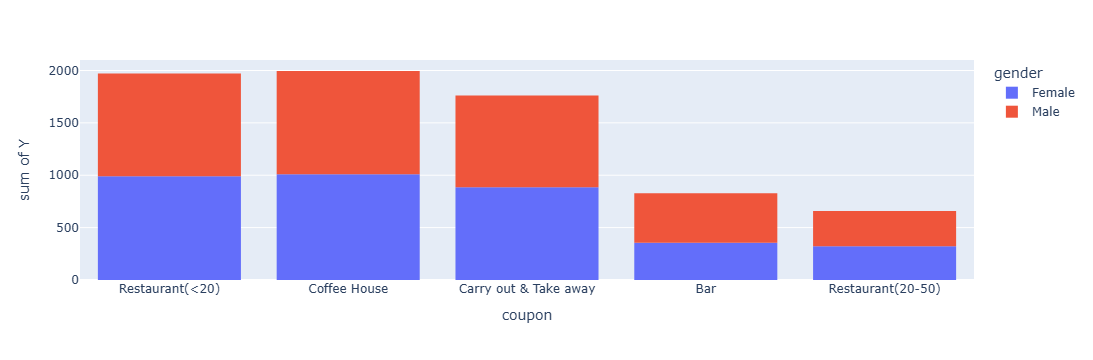

In [45]:
# it seems that gender has no part to play i.e. both genders equally accepted the coupon irrespective of type of coupon
px.histogram(data_frame=data , x='coupon', y='Y', color='gender')

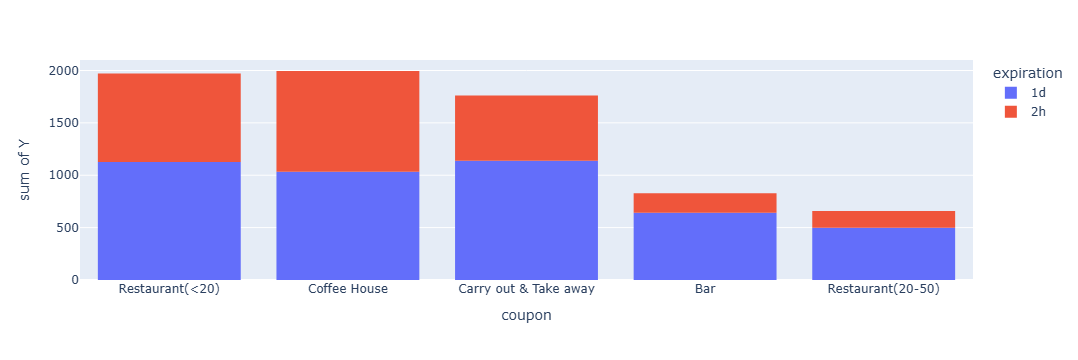

In [36]:
# A large majoriy of folks who acepted the coupons seem to prefer it for the entire day.
px.histogram(data_frame=data , x='coupon', y='Y', color='expiration')

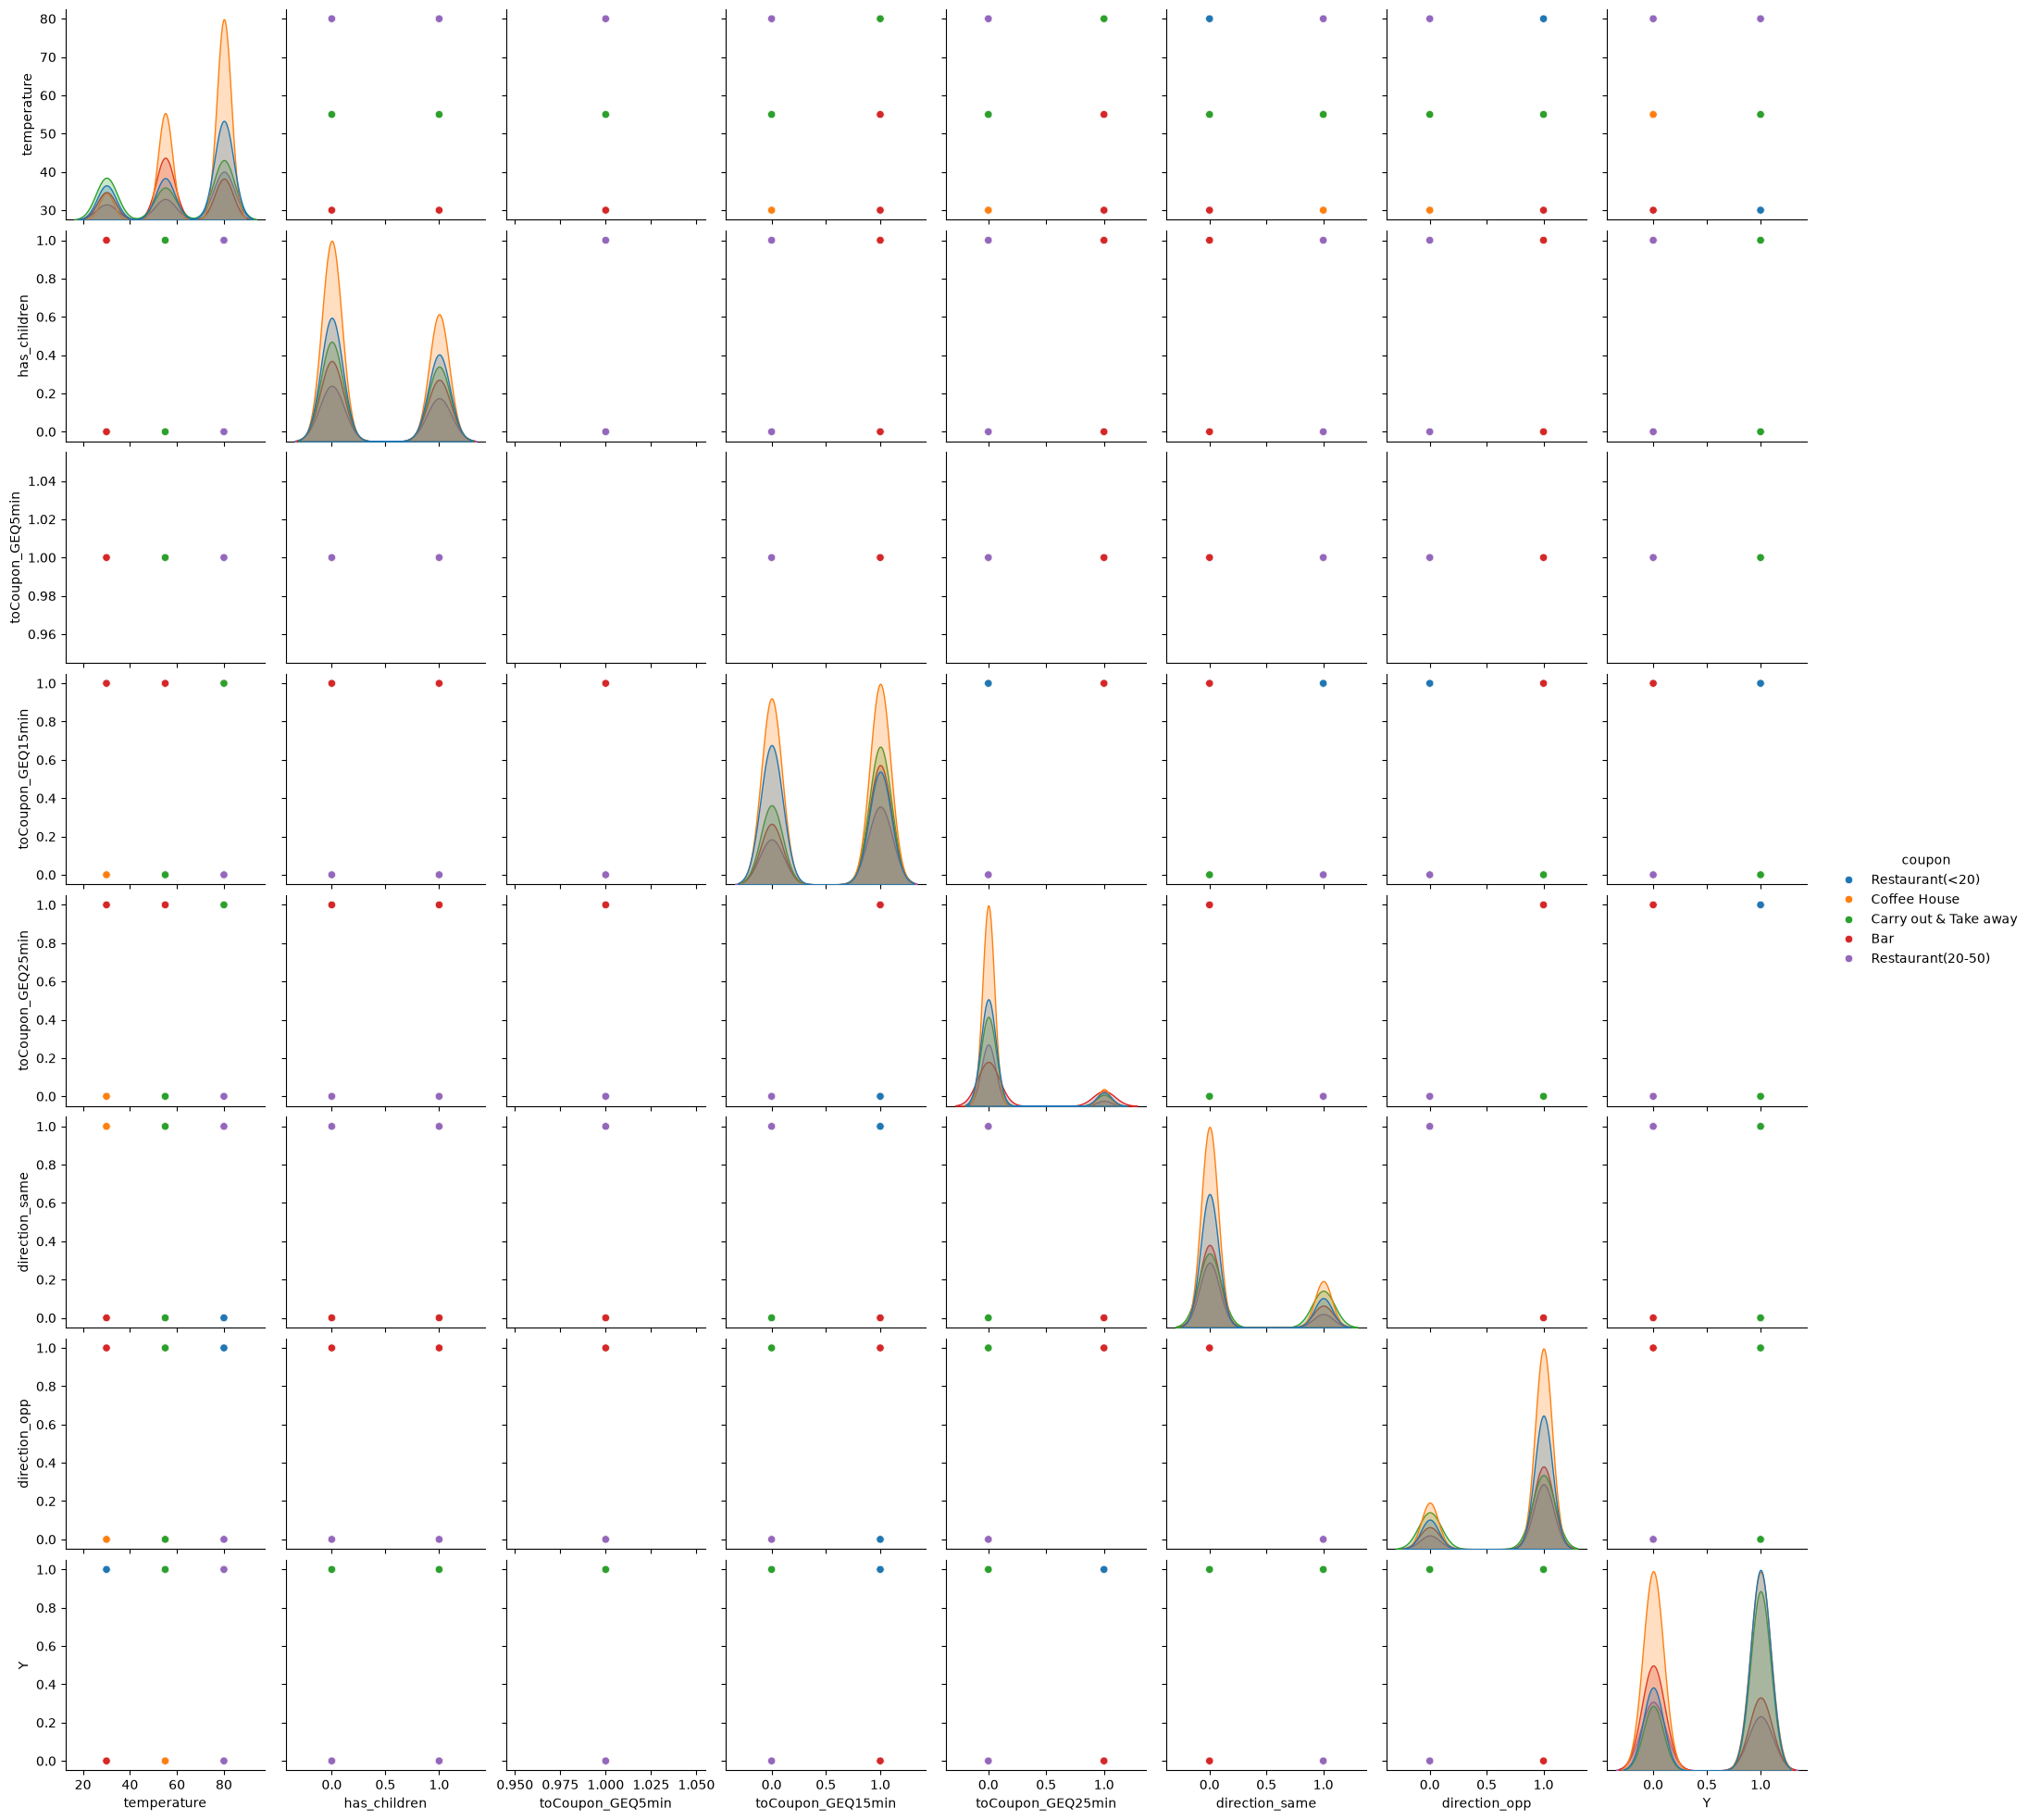

In [29]:
#while examining the pairplot below,it seems to confirm when i observed in previous queries. Ppl who accepted coupons seemed to prefer Restaurant(<20>
#when the temperature was around 30 so maybe morning but preferred carry out and takeaways when temperature was 60 so maybe afternoon and preferred
# restaurant(20-50) when temperature was 80 so later in the day. People who accepted coupons seemed to prefer carry out and take aways irrespective 
# of whether they had kids or not. People who accepted the coupon irrespective of whether they lived in the same direction or the opposite direction of 
# the food place and if it was really nice preffered takeouts/carry aways . However if the coupon was for a place 15 or 25 mins away , they preffered the 
#restaurant (< 20) . Most of the folks who declined the coupons seemed to have received offers of bars or restaurant (20-50) or coffee shops.


sns.pairplot(data, hue='coupon')